In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.ensemble import RandomForestClassifier

In [3]:
train_trans = pd.read_csv("train_transaction.csv")
train_id = pd.read_csv("train_identity.csv")


In [4]:
data = train_trans.merge(train_id, on="TransactionID", how="left")

In [5]:
data.shape


(8907, 434)

In [6]:
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [7]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8907 entries, 0 to 8906
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 29.5+ MB


In [8]:
missing_percentage = data.isnull().mean().sort_values(ascending=False)
missing_percentage.head(10)

,0
id_24,0.994836
id_22,0.994162
id_07,0.994162
id_08,0.994162
id_27,0.994162
id_23,0.994162
id_25,0.994162
id_26,0.994162
id_21,0.994162
D7,0.979342


In [9]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna("Unknown", inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)


/tmp/ipykernel_870/3871526236.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
/tmp/ipykernel_870/3871526236.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [10]:
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])


In [11]:
X = data.drop("isFraud", axis=1)
y = data["isFraud"]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


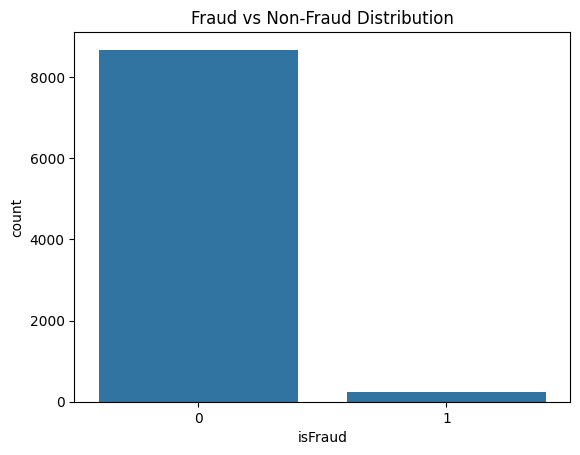

In [13]:
sns.countplot(x=y)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


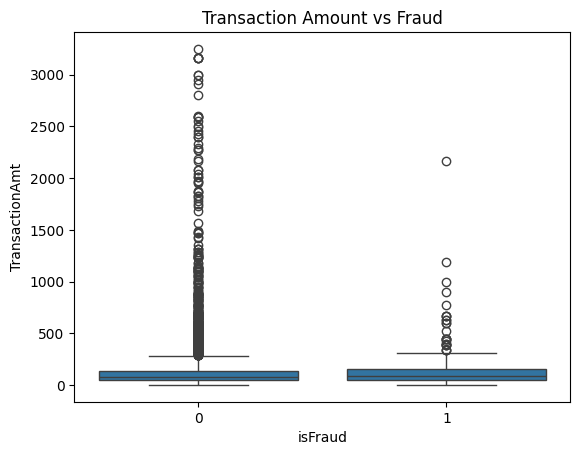

In [14]:
sns.boxplot(x='isFraud', y='TransactionAmt', data=data)
plt.title("Transaction Amount vs Fraud")
plt.show()


In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [16]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())


Before SMOTE:
isFraud
0    6936
1     189
Name: count, dtype: int64

After SMOTE:
isFraud
0    6936
1    6936
Name: count, dtype: int64


In [17]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [18]:
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_probs))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1735
           1       0.52      0.23      0.32        47

    accuracy                           0.97      1782
   macro avg       0.75      0.61      0.66      1782
weighted avg       0.97      0.97      0.97      1782

ROC-AUC Score: 0.8650683671592372


In [19]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
card6,0.050637
C2,0.041160
V280,0.028086
C11,0.025539
V308,0.025197
M4,0.023241
V317,0.020487
C5,0.019405
C6,0.018908
V292,0.017304


In [20]:
!pip install xgboost
from xgboost import XGBClassifier

In [21]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_probs))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1735
           1       0.66      0.53      0.59        47

    accuracy                           0.98      1782
   macro avg       0.82      0.76      0.79      1782
weighted avg       0.98      0.98      0.98      1782

ROC-AUC Score: 0.9077809798270893


In [23]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

results

,Model,ROC-AUC
0,Random Forest,0.865068
1,XGBoost,0.907781


In [24]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(10)

,0
V254,0.072358
V70,0.060580
V230,0.043571
card6,0.043062
C5,0.035019
card3,0.025381
V114,0.022067
M4,0.021981
V312,0.017917
V308,0.015181


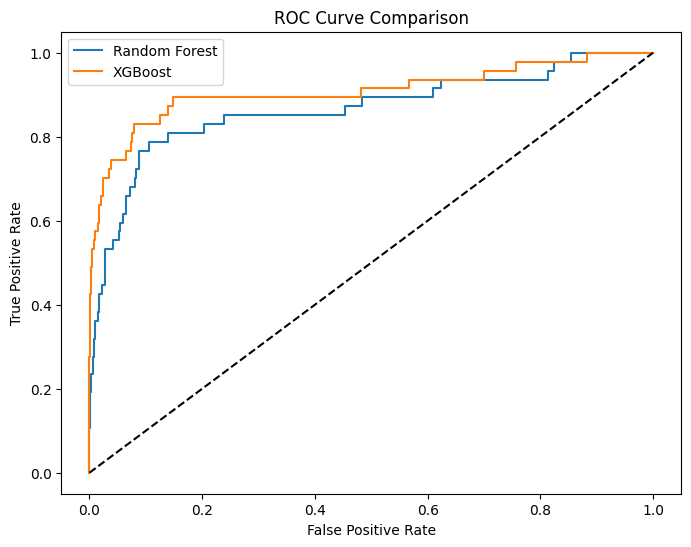

In [25]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [26]:
import pandas as pd

# Load test files
test_trans = pd.read_csv("test_transaction.csv")
test_id = pd.read_csv("test_identity.csv")

# Merge
test_data = test_trans.merge(test_id, on="TransactionID", how="left")

# Handle missing values
for col in test_data.columns:
    if test_data[col].dtype == 'object':
        test_data[col] = test_data[col].fillna("Unknown")
    else:
        test_data[col] = test_data[col].fillna(test_data[col].median())

# Encode categorical columns
for col in test_data.select_dtypes(include='object').columns:
    test_data[col] = test_data[col].astype('category').cat.codes

In [27]:
xgb.feature_names_in_

array(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1',
       'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1',
       'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7',
       'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2',
       'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4',
       'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14',
       'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23',
       'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32',
       'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41',
       'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50',
       'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59',
       'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68',
       

In [28]:
# 1. Add missing columns
for col in xgb.feature_names_in_:
    if col not in test_data.columns:
        test_data[col] = 0

# 2. Drop extra columns
test_data = test_data[xgb.feature_names_in_]

/tmp/ipykernel_870/2097303977.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data[col] = 0
/tmp/ipykernel_870/2097303977.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data[col] = 0
/tmp/ipykernel_870/2097303977.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data[col] = 

In [29]:
test_preds = xgb.predict_proba(test_data)[:, 1]

In [30]:
submission = pd.DataFrame({
    "TransactionID": test_trans["TransactionID"],
    "isFraud": test_preds
})

submission.to_csv("submission.csv", index=False)

In [31]:
from google.colab import files
files.download("submission.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>